## Model Training

#### 1.1 Import Data and Required Packages
##### Importing Pandas, Numpy, Matplotlib, Seaborn and Warings Library.

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

#### Import the CSV Data as Pandas DataFrame

In [2]:
df = pd.read_csv('stud.csv')

#### Show Top 5 Records

In [59]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Preparing X and Y variables

In [60]:
df['average'] = (df['math_score']+ df['reading_score']+ df['writing_score']) / 3

In [61]:
X = df.drop(columns=['average'])

In [62]:

print(df['gender'].unique())

print(df['race_ethnicity'].unique())

print(df['parental_level_of_education'].unique())

print(df['lunch'].unique())

print(df['test_preparation_course'].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str
<StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
<StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
<StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
<StringArray>
['none', 'completed']
Length: 2, dtype: str


In [63]:
y = df['average']

In [64]:
X.shape

(1000, 8)

In [65]:
# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
oh_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    [
        ("OneHotEncoder", oh_transformer, cat_features),
         ("StandardScaler", numeric_transformer, num_features)
    ]
                                )

C:\Users\Asus\AppData\Local\Temp\ipykernel_9292\151635867.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features = X.select_dtypes(include="object").columns


In [66]:
X = preprocessor.fit_transform(X)

In [67]:
X.shape

(1000, 20)

In [68]:
# separate dataset into train and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((800, 20), (200, 20))

#### Create an Evaluate Function to give all metrics after model Training

In [69]:
def evaluate_model(true, predicted):
    mae = mean_absolute_error(true, predicted)
    mse = mean_squared_error(true, predicted)
    rmse = np.sqrt(mean_squared_error(true, predicted))
    r2_scoree = r2_score(true, predicted)
    return mae, mse , rmse, r2_scoree

In [70]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Evaluate Train and Test dataset
    model_train_mae ,model_train_mse , model_train_rmse, model_train_r2 = evaluate_model(y_train, y_train_pred)

    model_test_mae , model_test_mse , model_test_rmse, model_test_r2 = evaluate_model(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- Mean Squared Error: {:.4f}".format(model_train_mse))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- Mean Squared Error: {:.4f}".format(model_test_mse))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)

    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- Mean Squared Error: 0.0000
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0000
- Mean Absolute Error: 0.0000
- Mean Squared Error: 0.0000
- R2 Score: 1.0000


Lasso
Model performance for Training set
- Root Mean Squared Error: 1.0645
- Mean Absolute Error: 0.8506
- Mean Squared Error: 1.1332
- R2 Score: 0.9943
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.1142
- Mean Absolute Error: 0.8769
- Mean Squared Error: 1.2414
- R2 Score: 0.9942


Ridge
Model performance for Training set
- Root Mean Squared Error: 0.0080
- Mean Absolute Error: 0.0065
- Mean Squared Error: 0.0001
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 0.0088
- Mean Absolute Error: 0.0067
- Mean Squared Error: 0.0001
- R2 Score

Random Forest Regressor
Model performance for Training set
- Root Mean Squared Error: 0.2826
- Mean Absolute Error: 0.1798
- Mean Squared Error: 0.0799
- R2 Score: 0.9996
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.1233
- Mean Absolute Error: 0.5208
- Mean Squared Error: 1.2619
- R2 Score: 0.9941


XGBRegressor
Model performance for Training set
- Root Mean Squared Error: 0.0570
- Mean Absolute Error: 0.0406
- Mean Squared Error: 0.0032
- R2 Score: 1.0000
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.0611
- Mean Absolute Error: 0.5534
- Mean Squared Error: 1.1258
- R2 Score: 0.9947


CatBoosting Regressor
Model performance for Training set
- Root Mean Squared Error: 0.1047
- Mean Absolute Error: 0.0842
- Mean Squared Error: 0.0110
- R2 Score: 0.9999
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 1.1852
- Mean Absolute Error: 0.3308
- Mean Squ

### Results

In [71]:
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
0,Linear Regression,1.000000
2,Ridge,1.000000
6,XGBRegressor,0.994748
1,Lasso,0.994209
5,Random Forest Regressor,0.994113
7,CatBoosting Regressor,0.993447
4,Decision Tree,0.986399
8,AdaBoost Regressor,0.977321
3,K-Neighbors Regressor,0.956016


## Linear Regression

In [72]:
lin_model = LinearRegression(fit_intercept=True)
lin_model = lin_model.fit(X_train, y_train)
y_pred = lin_model.predict(X_test)
score = r2_score(y_test, y_pred)*100
print(" Accuracy of the model is %.2f" %score)

 Accuracy of the model is 100.00


## Plot y_pred and y_test

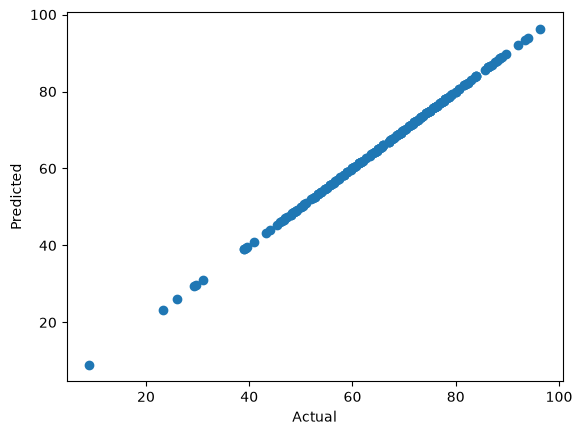

In [73]:
plt.scatter(y_test,y_pred);
plt.xlabel('Actual');
plt.ylabel('Predicted');

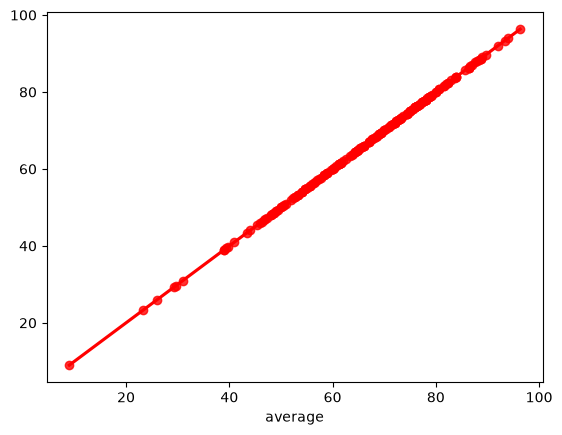

In [74]:
sns.regplot(x=y_test,y=y_pred,ci=None,color ='red');

#### Difference between Actual and Predicted Values

In [75]:
pred_df=pd.DataFrame({'Actual Value':y_test,'Predicted Value':y_pred,'Difference':y_test-y_pred})
pred_df

,Actual Value,Predicted Value,Difference
521,87.000000,87.000000,-1.421085e-14
737,64.000000,64.000000,1.421085e-14
740,75.000000,75.000000,0.000000e+00
660,74.666667,74.666667,1.421085e-14
411,81.666667,81.666667,0.000000e+00
...,...,...,...
408,55.000000,55.000000,2.131628e-14
332,57.000000,57.000000,1.421085e-14
208,77.000000,77.000000,0.000000e+00
613,72.000000,72.000000,0.000000e+00
